In [2]:
# Cell 1: Imports & GPU Environment Check
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import triton
import triton.language as tl

assert torch.cuda.is_available(), "CUDA GPU is required!"
print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"VRAM Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

Device: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM Total: 4.00 GB


In [3]:
# Cell 2: Triton Fused RMSNorm Forward + Analytical Backward
@triton.jit
def _rmsnorm_fwd_kernel(
    X_ptr, Y_ptr, W_ptr, R_ptr,
    stride_x_row, stride_y_row,
    N_COLS: tl.constexpr, EPS: tl.constexpr, BLOCK_SIZE: tl.constexpr
):
    row_idx = tl.program_id(0)
    col_offsets = tl.arange(0, BLOCK_SIZE)
    mask = col_offsets < N_COLS

    x_ptrs = X_ptr + row_idx * stride_x_row + col_offsets
    w_ptrs = W_ptr + col_offsets
    y_ptrs = Y_ptr + row_idx * stride_y_row + col_offsets

    x = tl.load(x_ptrs, mask=mask, other=0.0).to(tl.float32)
    w = tl.load(w_ptrs, mask=mask, other=0.0).to(tl.float32)

    # Compute variance across hidden dimension
    variance = tl.sum(x * x, axis=0) / N_COLS
    rsqrt = 1.0 / tl.sqrt(variance + EPS)

    # Save rsqrt per row for analytical backward derivation
    tl.store(R_ptr + row_idx, rsqrt)

    norm_x = x * rsqrt
    y = norm_x * w
    tl.store(y_ptrs, y.to(tl.float32), mask=mask)


@triton.jit
def _rmsnorm_bwd_kernel(
    dY_ptr, X_ptr, W_ptr, R_ptr, dX_ptr,
    stride_dy_row, stride_x_row, stride_dx_row,
    N_COLS: tl.constexpr, BLOCK_SIZE: tl.constexpr
):
    row_idx = tl.program_id(0)
    col_offsets = tl.arange(0, BLOCK_SIZE)
    mask = col_offsets < N_COLS

    dy_ptrs = dY_ptr + row_idx * stride_dy_row + col_offsets
    x_ptrs = X_ptr + row_idx * stride_x_row + col_offsets
    w_ptrs = W_ptr + col_offsets
    dx_ptrs = dX_ptr + row_idx * stride_dx_row + col_offsets

    dy = tl.load(dy_ptrs, mask=mask, other=0.0).to(tl.float32)
    x = tl.load(x_ptrs, mask=mask, other=0.0).to(tl.float32)
    w = tl.load(w_ptrs, mask=mask, other=0.0).to(tl.float32)
    rsqrt = tl.load(R_ptr + row_idx).to(tl.float32)

    # Analytical Derivative without caching intermediate activation tensors
    dy_w = dy * w
    sum_dy_w_x = tl.sum(dy_w * x, axis=0)
    dx = rsqrt * dy_w - (1.0 / N_COLS) * x * (rsqrt * rsqrt * rsqrt) * sum_dy_w_x

    tl.store(dx_ptrs, dx.to(tl.float32), mask=mask)


class FastRMSNormFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor, weight: torch.Tensor, eps: float = 1e-6):
        shape = x.shape
        x_2d = x.view(-1, shape[-1]).contiguous()
        n_rows, n_cols = x_2d.shape

        y_2d = torch.empty_like(x_2d)
        rsqrt = torch.empty(n_rows, device=x.device, dtype=torch.float32)
        BLOCK_SIZE = triton.next_power_of_2(n_cols)

        _rmsnorm_fwd_kernel[(n_rows,)](
            x_2d, y_2d, weight, rsqrt,
            x_2d.stride(0), y_2d.stride(0),
            N_COLS=n_cols, EPS=eps, BLOCK_SIZE=BLOCK_SIZE
        )

        ctx.save_for_backward(x_2d, weight, rsqrt)
        ctx.n_cols = n_cols
        ctx.BLOCK_SIZE = BLOCK_SIZE
        ctx.shape = shape
        return y_2d.view(shape)

    @staticmethod
    def backward(ctx, dy: torch.Tensor):
        x_2d, weight, rsqrt = ctx.saved_tensors
        dy_2d = dy.view(-1, ctx.n_cols).contiguous()
        dx_2d = torch.empty_like(x_2d)

        _rmsnorm_bwd_kernel[(x_2d.shape[0],)](
            dy_2d, x_2d, weight, rsqrt, dx_2d,
            dy_2d.stride(0), x_2d.stride(0), dx_2d.stride(0),
            N_COLS=ctx.n_cols, BLOCK_SIZE=ctx.BLOCK_SIZE
        )
        return dx_2d.view(ctx.shape), None, None


class FastRMSNorm(nn.Module):
    def __init__(self, hidden_size: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.eps = eps

    def forward(self, x: torch.Tensor):
        return FastRMSNormFunction.apply(x, self.weight, self.eps)

In [4]:
# Cell 4: Memory-Efficient Streaming Cross-Entropy
def chunked_cross_entropy_loss(
    hidden_states: torch.Tensor,
    lm_head_weight: torch.Tensor,
    target_ids: torch.Tensor,
    chunk_size: int = 128
) -> torch.Tensor:
    """
    Evaluates loss over small sequence slices, preventing full [B * L, Vocab]
    allocation in VRAM.
    """
    flat_hidden = hidden_states.view(-1, hidden_states.shape[-1])
    flat_targets = target_ids.view(-1)
    
    total_loss = torch.tensor(0.0, device=hidden_states.device, dtype=torch.float32)
    valid_tokens = 0

    for i in range(0, flat_hidden.shape[0], chunk_size):
        h_chunk = flat_hidden[i:i + chunk_size]
        y_chunk = flat_targets[i:i + chunk_size]

        mask = y_chunk != -100
        if not mask.any():
            continue

        # Transiently calculate only this chunk's logits
        logits_chunk = torch.matmul(h_chunk, lm_head_weight.T)
        chunk_loss = F.cross_entropy(logits_chunk[mask], y_chunk[mask], reduction="sum")
        
        total_loss += chunk_loss
        valid_tokens += mask.sum().item()
        del logits_chunk

    return total_loss / max(valid_tokens, 1)

In [5]:
# Cell 5: Run Warm Benchmark
device = torch.device("cuda:0")
B, L, D = 2, 1024, 2048  # Tuned for RTX 3050 memory limits

x = torch.randn(B, L, D, device=device, dtype=torch.float32, requires_grad=True)
dy = torch.randn(B, L, D, device=device, dtype=torch.float32)

fast_norm = FastRMSNorm(D).to(device)
torch_norm = nn.RMSNorm(D).to(device)

# --- 1. WARMUP (Compiles Triton JIT Kernels) ---
print("[*] Running Triton JIT Warmup...")
for _ in range(15):
    out_f = fast_norm(x)
    out_f.backward(dy)
    x.grad = None
    out_t = torch_norm(x)
    out_t.backward(dy)
    x.grad = None
torch.cuda.synchronize()

# --- 2. ACCURATE TIMING ---
runs = 50
start_e = torch.cuda.Event(enable_timing=True)
end_e = torch.cuda.Event(enable_timing=True)

# Triton timing
start_e.record()
for _ in range(runs):
    out_f = fast_norm(x)
    out_f.backward(dy)
    x.grad = None
end_e.record()
torch.cuda.synchronize()
fast_ms = start_e.elapsed_time(end_e) / runs

# PyTorch timing
start_e.record()
for _ in range(runs):
    out_t = torch_norm(x)
    out_t.backward(dy)
    x.grad = None
end_e.record()
torch.cuda.synchronize()
torch_ms = start_e.elapsed_time(end_e) / runs

print("\n" + "="*50)
print(f"PILLAR 1: RMSNorm Forward + Backward ({runs} runs averaged)")
print(f"Standard PyTorch RMSNorm: {torch_ms:.3f} ms")
print(f"Triton Fused RMSNorm:     {fast_ms:.3f} ms (Speedup: {torch_ms/fast_ms:.2f}x)")
print("="*50)

# --- 3. LOGIT VRAM PROFILING ---
V = 32000 # Vocab size
h = torch.randn(1, 512, 1024, device=device, dtype=torch.bfloat16)
lm_head = torch.randn(V, 1024, device=device, dtype=torch.bfloat16)
targets = torch.randint(0, V, (1, 512), device=device)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
full_logits = torch.matmul(h, lm_head.T)
loss_std = F.cross_entropy(full_logits.view(-1, V), targets.view(-1))
mem_std = torch.cuda.max_memory_allocated() / (1024**2)

del full_logits, loss_std
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

loss_chunk = chunked_cross_entropy_loss(h, lm_head, targets, chunk_size=64)
mem_chunk = torch.cuda.max_memory_allocated() / (1024**2)

print("\n" + "="*50)
print("PILLAR 3: Cross-Entropy Loss VRAM Profile")
print(f"Standard Full Logits Peak VRAM:   {mem_std:.2f} MB")
print(f"Streaming Chunked Loss Peak VRAM: {mem_chunk:.2f} MB")
print(f"VRAM Reduction Factor:            {mem_std/mem_chunk:.2f}x less VRAM")
print("="*50)

[*] Running Triton JIT Warmup...

PILLAR 1: RMSNorm Forward + Backward (50 runs averaged)
Standard PyTorch RMSNorm: 3.044 ms
Triton Fused RMSNorm:     0.832 ms (Speedup: 3.66x)

PILLAR 3: Cross-Entropy Loss VRAM Profile
Standard Full Logits Peak VRAM:   1762.11 MB
Streaming Chunked Loss Peak VRAM: 1711.33 MB
VRAM Reduction Factor:            1.03x less VRAM


# Comparison on Qwen 0.5 B

In [1]:
# =====================================================================
# CELL 1: SETUP, RECOVERY & SHARED DATASET
# =====================================================================
import gc
import sys
import time
import types
import importlib.machinery
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Polyfill dummy torchao for Windows compatibility
if "torchao" not in sys.modules or not hasattr(sys.modules["torchao"], "__spec__"):
    dummy_torchao = types.ModuleType("torchao")
    dummy_torchao.__spec__ = importlib.machinery.ModuleSpec("torchao", None)
    dummy_torchao.__version__ = "0.8.0"
    for sub in ["quantization", "dtypes"]:
        mod = types.ModuleType(f"torchao.{sub}")
        mod.__spec__ = importlib.machinery.ModuleSpec(f"torchao.{sub}", None)
        sys.modules[f"torchao.{sub}"] = mod
    sys.modules["torchao"] = dummy_torchao

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    TrainerCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = "Qwen/Qwen2.5-0.5B"
MAX_SEQ_LEN = 512

# 1. Load Real Dataset
raw_ds = load_dataset("yahma/alpaca-cleaned", split="train")
train_dataset = raw_ds.select(range(0, 150))
eval_dataset = raw_ds.select(range(150, 180))

# Shared Callback for Step-by-Step Metrics
class BenchmarkCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []
        self.vram_mb = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])
            self.vram_mb.append(torch.cuda.memory_allocated() / (1024**2))

def build_masked_dataset(tokenizer):
    """Applies strict response-only loss masking (-100 on prompt tokens)."""
    def tokenize_func(example):
        user_msg = f"{example['instruction']}\n\nContext:\n{example['input']}" if example.get("input", "").strip() else example["instruction"]
        prompt_part = f"<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n"
        response_part = f"{example['output']}<|im_end|>"

        prompt_ids = tokenizer.encode(prompt_part, add_special_tokens=False)
        response_ids = tokenizer.encode(response_part, add_special_tokens=False)

        input_ids = (prompt_ids + response_ids)[:MAX_SEQ_LEN]
        labels = ([-100] * len(prompt_ids) + response_ids)[:MAX_SEQ_LEN]

        return {"input_ids": input_ids, "labels": labels}

    return train_dataset.map(tokenize_func, remove_columns=train_dataset.column_names)

print(f"[*] Base setup ready on GPU: {torch.cuda.get_device_name(0)}")

c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[*] Base setup ready on GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# =====================================================================
# CELL 2: PIPELINE 1 — STANDARD HUGGING FACE 4-BIT QLoRA
# =====================================================================
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
time.sleep(2)

print("\n" + "="*60)
print("[*] STARTING PIPELINE 1: STANDARD HUGGING FACE 4-BIT QLoRA")
print(f"[*] Initial Active VRAM: {torch.cuda.memory_allocated() / (1024**2):.2f} MB")
print("="*60)

tokenizer_hf = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer_hf.pad_token is None:
    tokenizer_hf.pad_token = tokenizer_hf.eos_token

ds_train_hf = build_masked_dataset(tokenizer_hf)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_hf = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0}
)
model_hf = prepare_model_for_kbit_training(model_hf)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM"
)
model_hf = get_peft_model(model_hf, lora_config)

args_hf = TrainingArguments(
    output_dir="./artifacts_hf",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    logging_steps=5,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

callback_hf = BenchmarkCallback()

torch.cuda.synchronize()
start_t_hf = time.time()

trainer_hf = Trainer(
    model=model_hf,
    args=args_hf,
    train_dataset=ds_train_hf,
    data_collator=DataCollatorForSeq2Seq(tokenizer_hf, pad_to_multiple_of=8),
    callbacks=[callback_hf]
)
trainer_hf.train()

torch.cuda.synchronize()
time_hf = time.time() - start_t_hf
peak_vram_hf = torch.cuda.max_memory_allocated() / (1024**3)

print(f"\n[+] HF QLoRA Result -> Peak VRAM: {peak_vram_hf:.2f} GB | Runtime: {time_hf:.2f} s")

# Cleanup memory completely
del model_hf, trainer_hf, ds_train_hf, tokenizer_hf
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
time.sleep(2)


[*] STARTING PIPELINE 1: STANDARD HUGGING FACE 4-BIT QLoRA
[*] Initial Active VRAM: 0.00 MB


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,1.518700
10,1.448800
15,1.567800
20,1.625100
25,1.271500
30,1.192000
35,1.314200
40,1.469000
45,1.322600
50,1.240500



[+] HF QLoRA Result -> Peak VRAM: 2.78 GB | Runtime: 219.99 s


In [3]:
# =====================================================================
# CELL 3: PIPELINE 2 — UNSLOTH 4-BIT QLoRA
# =====================================================================
# Import Unsloth dynamically now so it does not pollute Pipeline 1
from unsloth import FastLanguageModel

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
time.sleep(2)

print("\n" + "="*60)
print("[*] STARTING PIPELINE 2: UNSLOTH 4-BIT QLoRA")
print(f"[*] Initial Active VRAM: {torch.cuda.memory_allocated() / (1024**2):.2f} MB")
print("="*60)

model_unsloth, tokenizer_unsloth = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=MAX_SEQ_LEN,
    dtype=torch.float16,
    load_in_4bit=True,
)

model_unsloth = FastLanguageModel.get_peft_model(
    model_unsloth,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth"
)

ds_train_unsloth = build_masked_dataset(tokenizer_unsloth)

args_unsloth = TrainingArguments(
    output_dir="./artifacts_unsloth",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    logging_steps=5,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

callback_unsloth = BenchmarkCallback()

torch.cuda.synchronize()
start_t_unsloth = time.time()

trainer_unsloth = Trainer(
    model=model_unsloth,
    args=args_unsloth,
    train_dataset=ds_train_unsloth,
    data_collator=DataCollatorForSeq2Seq(tokenizer_unsloth, pad_to_multiple_of=8),
    callbacks=[callback_unsloth]
)
trainer_unsloth.train()

torch.cuda.synchronize()
time_unsloth = time.time() - start_t_unsloth
peak_vram_unsloth = torch.cuda.max_memory_allocated() / (1024**3)

print(f"\n[+] Unsloth Result -> Peak VRAM: {peak_vram_unsloth:.2f} GB | Runtime: {time_unsloth:.2f} s")

c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\unsloth\__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *
[fla.utils._device|WARNING]Current Python version 3.10 is below the recommended 3.11 version. It is recommended to upgrade to Python 3.11 or higher for the best experience.


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0815 09:54:12.838000 30036 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!

[*] STARTING PIPELINE 2: UNSLOTH 4-BIT QLoRA
[*] Initial Active VRAM: 16.25 MB
==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3050 Laptop GPU. Num GPUs = 1. Max memory: 4.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.7.1+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.8.18 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.
Map: 100%|██████████| 150/150 [00:00<00:00, 418.90 examples/s]
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 150 | Num Epochs = 2 | Total steps = 76
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 4,399,104 of 498,431,872 (0.88% trained)


Step,Training Loss
5,1.511700
10,1.450800
15,1.550500
20,1.611300
25,1.255300
30,1.186700
35,1.318000
40,1.490200
45,1.298000
50,1.232000



[+] Unsloth Result -> Peak VRAM: 2.60 GB | Runtime: 158.50 s


C:\Users\ujwal\AppData\Local\Temp\ipykernel_30036\2717427782.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vram, x='Engine', y='Peak VRAM (GB)', ax=axes[0, 1], palette=['#e74c3c', '#27ae60'])
C:\Users\ujwal\AppData\Local\Temp\ipykernel_30036\2717427782.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tps, x='Engine', y='Tokens/Sec', ax=axes[1, 0], palette=['#e74c3c', '#27ae60'])
C:\Users\ujwal\AppData\Local\Temp\ipykernel_30036\2717427782.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Engine'

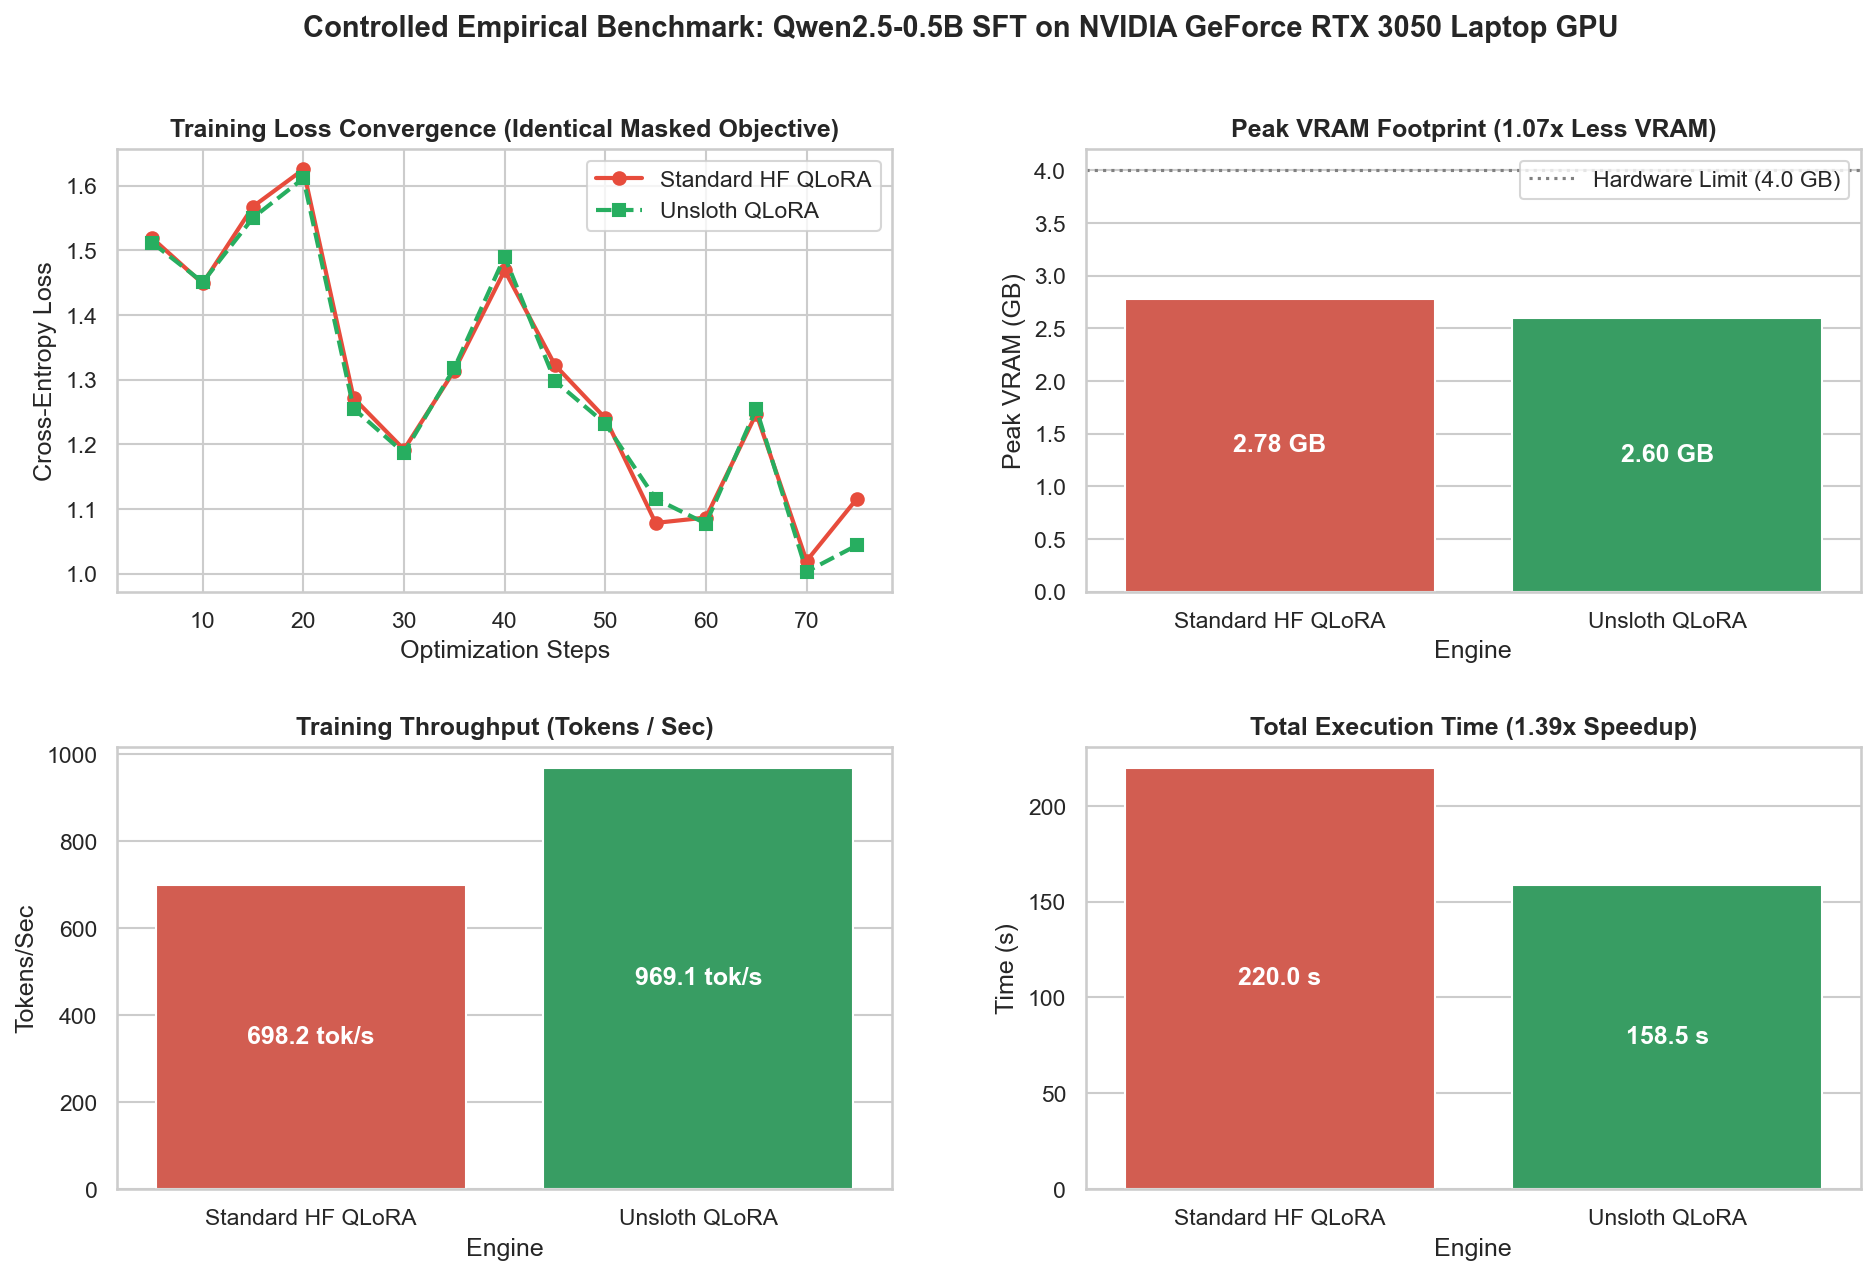


Saved publication-ready figure: 'benchmark_comparison_linkedin.png'


In [4]:
# =====================================================================
# CELL 4: BENCHMARK PLOTTING (FOR LINKEDIN PUBLICATION)
# =====================================================================
gpu_name = torch.cuda.get_device_name(0)
total_vram_limit = torch.cuda.get_device_properties(0).total_memory / (1024**3)

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=150)
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Loss Curves
axes[0, 0].plot(callback_hf.steps, callback_hf.losses, marker='o', color='#e74c3c', label='Standard HF QLoRA', linewidth=2)
axes[0, 0].plot(callback_unsloth.steps, callback_unsloth.losses, marker='s', linestyle='--', color='#27ae60', label='Unsloth QLoRA', linewidth=2)
axes[0, 0].set_title("Training Loss Convergence (Identical Masked Objective)", fontweight='bold')
axes[0, 0].set_xlabel("Optimization Steps")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].legend()

# 2. Peak Active VRAM
df_vram = pd.DataFrame({
    'Engine': ['Standard HF QLoRA', 'Unsloth QLoRA'],
    'Peak VRAM (GB)': [peak_vram_hf, peak_vram_unsloth]
})
sns.barplot(data=df_vram, x='Engine', y='Peak VRAM (GB)', ax=axes[0, 1], palette=['#e74c3c', '#27ae60'])
axes[0, 1].axhline(total_vram_limit, color='grey', linestyle=':', label=f'Hardware Limit ({total_vram_limit:.1f} GB)')
axes[0, 1].set_title(f"Peak VRAM Footprint ({peak_vram_hf/peak_vram_unsloth:.2f}x Less VRAM)", fontweight='bold')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.2f} GB", 
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')
axes[0, 1].legend()

# 3. Throughput
tps_hf = (len(train_dataset) * 2 * MAX_SEQ_LEN) / time_hf
tps_unsloth = (len(train_dataset) * 2 * MAX_SEQ_LEN) / time_unsloth
df_tps = pd.DataFrame({
    'Engine': ['Standard HF QLoRA', 'Unsloth QLoRA'],
    'Tokens/Sec': [tps_hf, tps_unsloth]
})
sns.barplot(data=df_tps, x='Engine', y='Tokens/Sec', ax=axes[1, 0], palette=['#e74c3c', '#27ae60'])
axes[1, 0].set_title("Training Throughput (Tokens / Sec)", fontweight='bold')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.1f} tok/s", 
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

# 4. Total Training Latency
df_time = pd.DataFrame({
    'Engine': ['Standard HF QLoRA', 'Unsloth QLoRA'],
    'Time (s)': [time_hf, time_unsloth]
})
sns.barplot(data=df_time, x='Engine', y='Time (s)', ax=axes[1, 1], palette=['#e74c3c', '#27ae60'])
axes[1, 1].set_title(f"Total Execution Time ({time_hf/time_unsloth:.2f}x Speedup)", fontweight='bold')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} s", 
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

plt.suptitle(f"Controlled Empirical Benchmark: Qwen2.5-0.5B SFT on {gpu_name}", fontsize=14, fontweight='heavy')
plt.savefig("benchmark_comparison_linkedin.png", bbox_inches='tight', dpi=300)
plt.show()

print("\nSaved publication-ready figure: 'benchmark_comparison_linkedin.png'")